In [1]:
import copy
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader

PROJECT_DIR = Path.cwd().parent
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from architectures.criterion import HungarianMatcher, SetCriterion
from architectures.deformable_detr import ASTDeformableDETR, postprocess
from core.config import P, settings
from core.setup import setup_data, setup_logging, setup_project_path
from domain.annotations import load_annotations
from domain.dataset import LABEL_INDEX, CallBoxDataset, build_manifest, collate_fn, split_manifest
from domain.species import LabelSet
from pipelines.training_pipeline import evaluate, train_one_epoch

setup_logging(settings.LOG_LEVEL)
setup_project_path(PROJECT_DIR)
setup_data()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLEANED_DIR = settings.data_dir / "cleaned"
print(f"device: {DEVICE}")

[2026-07-27 22:54:14] [INFO] [core.setup] Ruta del proyecto configurada en: /home/nhrot/Prog/tesis-primate
[2026-07-27 22:54:14] [INFO] [core.setup] Datos existentes en /home/nhrot/Prog/tesis-primate/data/raw. Omitiendo.


device: cuda


In [12]:
for name, value in {
    "clip_len_s": 3.0,
    "clip_hop_s": 1.5,
    "min_overlap": 0.5,
    "target_sr": 44_100,
    "n_fft": 4096,
    "win_length": 4000,
    "hop_length": 400,
    "n_mels": 256,
    "f_min": 0.0,
    "f_max": 16_000.0,
}.items():
    setattr(P, name, value)

SEED = 42
EXPERIMENT_PAIRS = [("ac", "bc"), ("lw", "cs"), ("sm", "cc"), ("as", "bc"), ("sb", "ppc")]
LABEL_BY = "species/call_type"

MODEL_DIM, N_QUERIES, IOU_TYPE = 128, 64, "eiou"
EPOCHS, BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY, NUM_WORKERS = 200, 32, 2e-4, 1e-4, 0
EVAL_EVERY = 10
SCORE_THR, IOU_THR = 0.5, 0.5

print(f"clip {P.clip_len_s}s @ {P.target_sr} Hz -> espectrograma {P.n_mels} x {P.n_frames}")

clip 3.0s @ 44100 Hz -> espectrograma 256 x 331


In [7]:
annotations = load_annotations(CLEANED_DIR)

print(f"{len(annotations)} anotaciones | {annotations.species.nunique()} especies")
annotations.groupby(["species", "call_type"]).size().sort_values(ascending=False).head(10)

19042 anotaciones | 8 especies


species  call_type
ac       bc           2487
lw       cs           2316
sm       cc           2040
as       bc           1909
         hc           1401
sb       ppc          1151
aa       gc            796
sb       spc           730
sm       fs            691
pt       dc            638
dtype: int64

In [8]:
LABEL_COLUMN = {
    "call": lambda df: "call",
    "species": lambda df: df["species"],
    "species/call_type": lambda df: df["species"] + "/" + df["call_type"],
}

pairs = annotations[["species", "call_type"]].apply(tuple, axis=1)
experiment_df = annotations[pairs.isin(EXPERIMENT_PAIRS)].copy()
experiment_df["label"] = LABEL_COLUMN[LABEL_BY](experiment_df)

LABELS = LabelSet(experiment_df["label"])
N_CLASSES = len(LABELS)

print(f"{len(experiment_df)} anotaciones | {N_CLASSES} clases: {', '.join(LABELS.names)}")
experiment_df.groupby("label").agg(
    n=("duration_s", "size"),
    duration_s=("duration_s", "mean"),
    bandwidth_hz=("bandwidth_hz", "mean"),
    low_freq_hz=("low_freq_hz", "mean"),
    high_freq_hz=("high_freq_hz", "mean"),
)

9903 anotaciones | 5 clases: ac/bc, as/bc, lw/cs, sb/ppc, sm/cc


,n,duration_s,bandwidth_hz,low_freq_hz,high_freq_hz
label,,,,,
ac/bc,2487,0.374363,2693.778553,398.228138,3092.006691
as/bc,1909,0.363763,601.498373,100.002636,701.501009
lw/cs,2316,0.420314,2102.249104,8011.211649,10113.460752
sb/ppc,1151,0.231251,4188.038937,7081.193507,11269.232445
sm/cc,2040,0.091552,3052.746553,529.105539,3581.852092


In [9]:
manifest = build_manifest(experiment_df, LABELS)
train_m, val_m, test_m = split_manifest(manifest, seed=SEED)
train_ds, val_ds, test_ds = (CallBoxDataset(windows) for windows in (train_m, val_m, test_m))


def make_loader(dataset: CallBoxDataset, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
        pin_memory=True,
    )


train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)

class_counts = Counter(
    LABELS.name(class_id) for window in train_m for class_id in window.boxes[:, LABEL_INDEX]
)
print(f"ventanas -> train {len(train_m)} | val {len(val_m)} | test {len(test_m)}")
print(f"cajas en train -> {dict(class_counts.most_common())}")

ventanas -> train 6298 | val 806 | test 1796
cajas en train -> {'ac/bc': 3583, 'lw/cs': 3233, 'sm/cc': 2696, 'as/bc': 2510, 'sb/ppc': 1553}


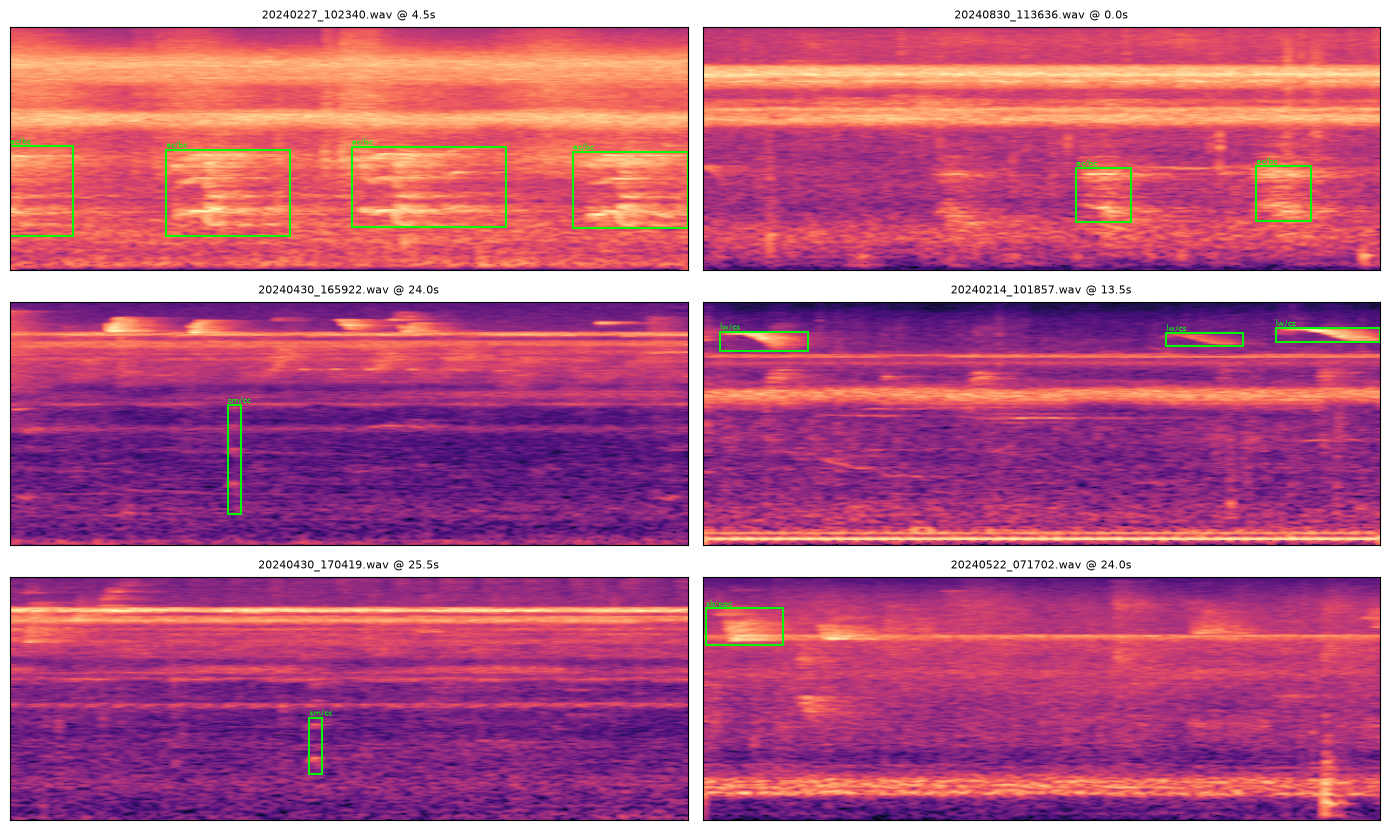

In [10]:
def plot_clips(dataset, indices, detections=None, ncols=2):
    nrows = (len(indices) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 2.8 * nrows), squeeze=False)
    panels = axes.ravel()
    for ax in panels[len(indices) :]:
        ax.axis("off")

    for position, index in enumerate(indices):
        ax = panels[position]
        log_mel, target = dataset[index]
        spectrogram = log_mel.squeeze(0).numpy()
        n_mels, n_frames = spectrogram.shape

        ax.imshow(
            spectrogram,
            origin="lower",
            aspect="auto",
            cmap="magma",
            extent=(0, n_frames, 0, n_mels),
        )
        ax.set_xticks([])
        ax.set_yticks([])

        overlays = [(target["boxes"], target["labels"], None, "lime")]
        if detections is not None:
            found = detections[position]
            overlays.append((found.boxes, found.labels, found.scores, "red"))

        for boxes, labels, scores, color in overlays:
            for box_index, (box, label) in enumerate(zip(boxes, labels, strict=True)):
                cx, cy, width, height = box.tolist()
                x0, y0 = (cx - width / 2) * n_frames, (cy - height / 2) * n_mels
                ax.add_patch(
                    mpatches.Rectangle(
                        (x0, y0),
                        width * n_frames,
                        height * n_mels,
                        fill=False,
                        edgecolor=color,
                        lw=1.4,
                    )
                )
                text = LABELS.name(int(label))
                if scores is not None:
                    text += f" {scores[box_index]:.2f}"
                ax.text(x0, y0 + height * n_mels, text, color=color, fontsize=6, va="bottom")

        window = dataset.manifest[index]
        ax.set_title(f"{Path(window.audio_path).name} @ {window.clip_start_s:.1f}s", fontsize=8)

    fig.tight_layout()
    return fig


sample_indices = np.random.default_rng(SEED).choice(len(train_ds), size=6, replace=False)
plot_clips(train_ds, sample_indices)
plt.show()

In [11]:
torch.manual_seed(SEED)

model = ASTDeformableDETR(dim=MODEL_DIM, n_queries=N_QUERIES, n_classes=N_CLASSES).to(DEVICE)
criterion = SetCriterion(
    n_classes=N_CLASSES,
    matcher=HungarianMatcher(iou_type=IOU_TYPE),
    iou_type=IOU_TYPE,
).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    total_steps=EPOCHS * len(train_loader),
    pct_start=0.05,
    anneal_strategy="cos",
)

print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parámetros | {N_CLASSES} clases")

4.3M parámetros | 5 clases


/home/nhrot/Prog/tesis-primate/src/architectures/backbone.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


In [13]:
train_history: dict[str, list[float]] = defaultdict(list)
val_history: dict[str, list[float]] = defaultdict(list)
val_epochs: list[int] = []
best_val, best_state = float("inf"), None

for epoch in range(EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, DEVICE)
    for name, value in train_metrics.items():
        train_history[name].append(value)

    if epoch and (epoch + 1) % EVAL_EVERY:
        continue

    val_metrics = evaluate(model, val_loader, criterion, DEVICE, SCORE_THR, IOU_THR, IOU_TYPE)
    val_epochs.append(epoch)
    for name, value in val_metrics.items():
        val_history[name].append(value)

    print(
        f"[{epoch + 1:>4}/{EPOCHS}] train={train_metrics['total']:.3f} "
        f"val={val_metrics['total']:.3f} "
        f"P={val_metrics['precision']:.3f} R={val_metrics['recall']:.3f} "
        f"F1={val_metrics['f1']:.3f} cls={val_metrics['cls_acc']:.3f}"
    )

    if val_metrics["total"] < best_val:
        best_val, best_state = val_metrics["total"], copy.deepcopy(model.state_dict())
        torch.save(best_state, PROJECT_DIR / "best_model_state.pth")

if best_state is None:
    raise RuntimeError("No se completó ninguna época.")
model.load_state_dict(best_state)
print(f"mejor pérdida de validación: {best_val:.3f}")

[   1/200] train=5.125 val=3.842 P=0.429 R=0.012 F1=0.023 cls=1.000
[  10/200] train=2.144 val=2.341 P=0.133 R=0.310 F1=0.187 cls=0.993
[  20/200] train=1.472 val=1.812 P=0.272 R=0.482 F1=0.348 cls=0.998
[  30/200] train=1.124 val=1.759 P=0.318 R=0.530 F1=0.397 cls=0.999


KeyboardInterrupt: 

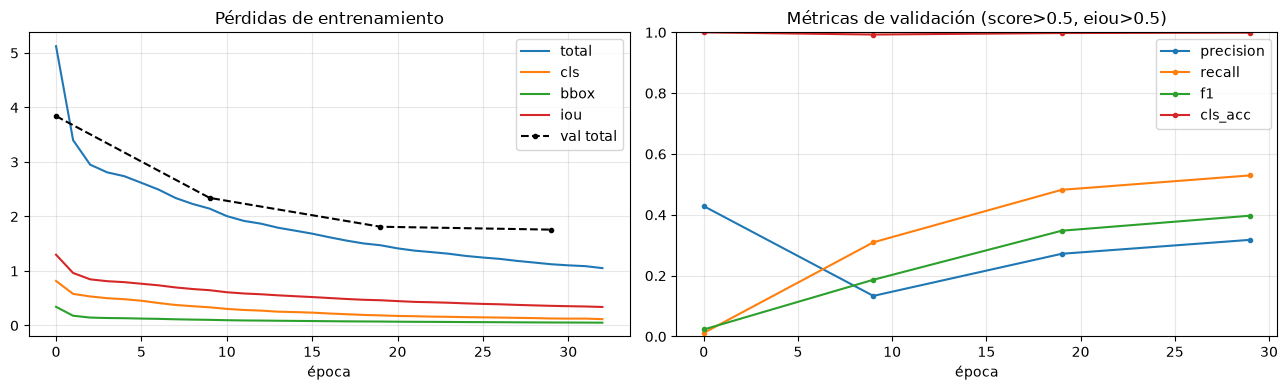

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name in ("total", "cls", "bbox", "iou"):
    axes[0].plot(train_history[name], label=name)
axes[0].plot(val_epochs, val_history["total"], "o--", color="black", ms=3, label="val total")
axes[0].set_title("Pérdidas de entrenamiento")
axes[0].set_xlabel("época")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name in ("precision", "recall", "f1", "cls_acc"):
    axes[1].plot(val_epochs, val_history[name], marker="o", ms=3, label=name)
axes[1].set_title(f"Métricas de validación (score>{SCORE_THR}, {IOU_TYPE}>{IOU_THR})")
axes[1].set_xlabel("época")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(settings.data_dir / "training_curves.png", dpi=150)
plt.show()

total=1.731 | cls=0.243 | bbox=0.088 | iou=0.525 | precision=0.296 | recall=0.521 | f1=0.377 | cls_acc=1.000


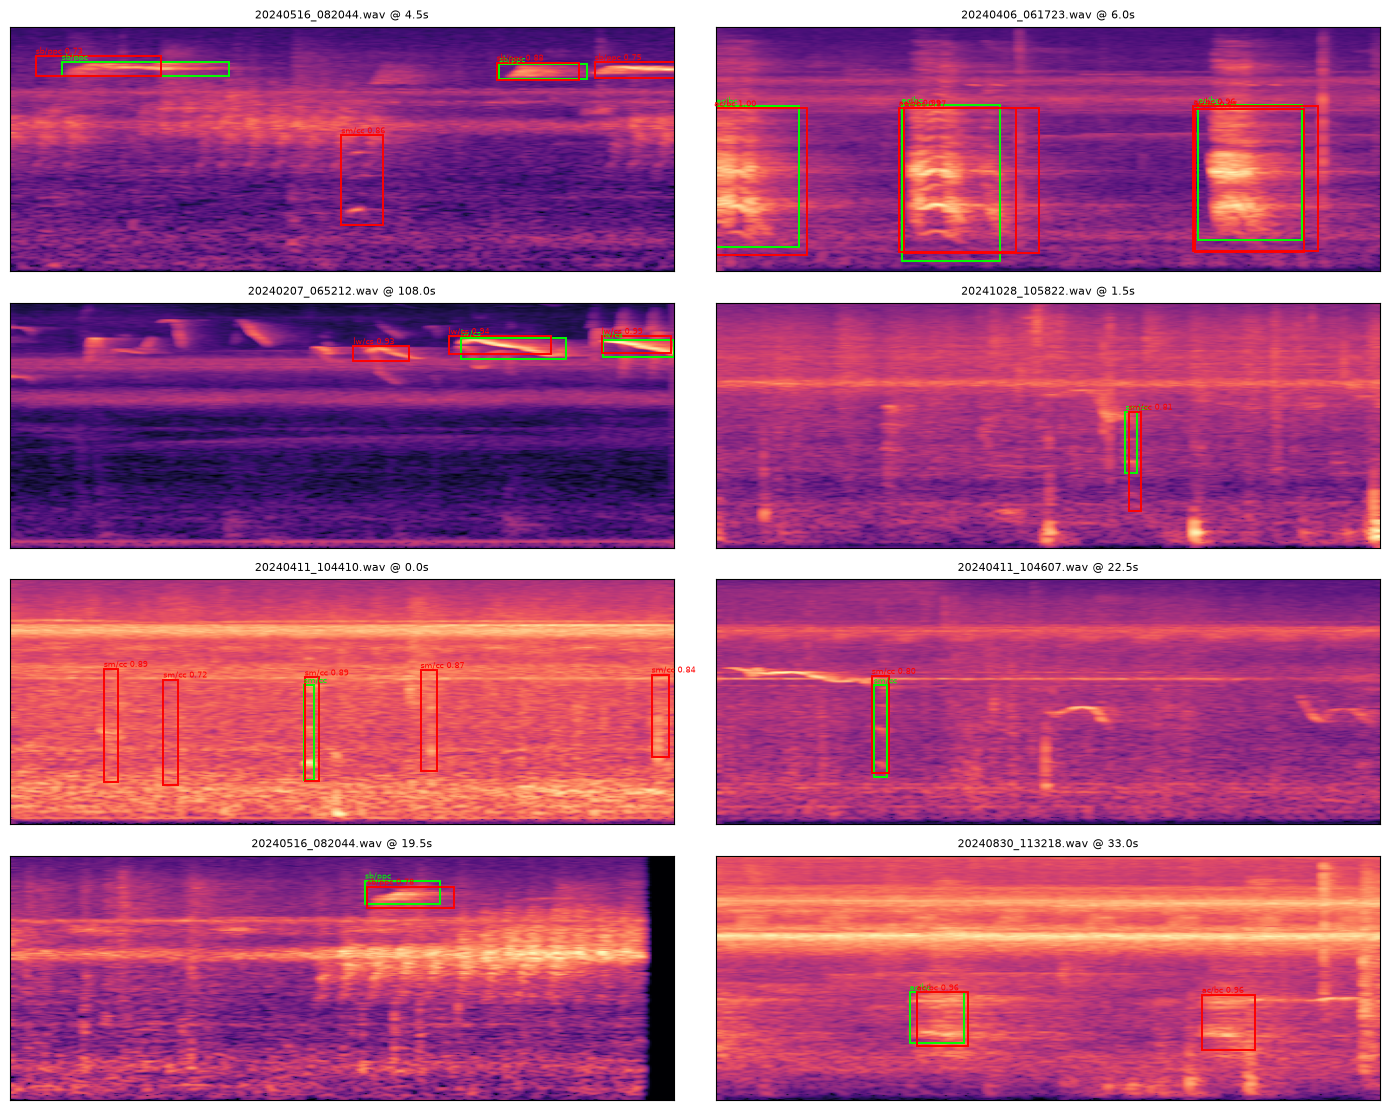

In [15]:
test_metrics = evaluate(model, test_loader, criterion, DEVICE, SCORE_THR, IOU_THR, IOU_TYPE)
print(" | ".join(f"{name}={value:.3f}" for name, value in test_metrics.items()))

test_indices = np.random.default_rng(SEED).choice(
    len(test_ds), size=min(8, len(test_ds)), replace=False
)
images = torch.stack([test_ds[index][0] for index in test_indices]).to(DEVICE)

model.eval()
with torch.no_grad():
    detections = postprocess(model(images), SCORE_THR)

plot_clips(test_ds, test_indices, detections)
plt.show()